# 10 — English hotel reviews: audit and preparation

**New data, new target domain.** The project pivots from French film reviews
to **English hotel reviews** — real customer feedback about a product, which is
the business question the system was built to answer. The film-review domain
gap, flagged as the main open risk throughout, disappears.

### Why review level, and why star ratings

The source file ships a `sentiment` column, but it is **machine-generated**
(`source_aspect` reads `bertopic` / `cosine`). Checked against the star
ratings it disagrees on **15.7%** of unambiguous sentences, with visible
errors — *"Room unworthy of a hotel Accor."* is labelled positive.

Filtering by its confidence score fixes reliability but destroys balance: at
`score >= 0.9` the data is 80% positive, because the confident predictions are
the easy positives. Trading away both minority classes to buy label quality is
a bad deal.

`note` — the star rating — is the one genuine human label in the file. So:

| | Choice |
|---|---|
| Unit | the **review**, reconstructed from its sentences |
| Label | **star rating**, mapped to 3 classes |
| Auto-sentiment | kept as a **baseline to beat**, never as training signal |

The sentence-level aspect assignments stay useful for the breakdown layer —
*which topic* a sentence is about is a much easier judgement than its
sentiment, and it is checked separately in notebook 13.

In [1]:
import sys, json, time
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION

SRC = REPO / "dataset for training in ENGLISH" / "df_final_absa_v4.csv"
OUT = REPO / "data_en"; OUT.mkdir(exist_ok=True)
LABELS = ["negative", "neutral", "positive"]

raw = pd.read_csv(SRC)
print(f"all languages: {len(raw):,} sentences")
print("langue:", dict(raw.langue.value_counts()))
en = raw[raw.langue == "Anglais"].copy().sort_values("avis_id").reset_index(drop=True)
print(f"\nEnglish: {len(en):,} sentences")
print("NOTE: 52,324 French sentences are also in this file -- the French track")
print("      could be rebuilt on real hotel data too, if wanted.")

all languages: 102,465 sentences
langue: {'Français': np.int64(52324), 'Anglais': np.int64(32625), 'Espagnol': np.int64(5010), 'Italien': np.int64(3404), 'Allemand': np.int64(2948), 'Portugais': np.int64(2061), 'Néerlandais': np.int64(1815), 'Russe': np.int64(879), 'Arabe': np.int64(735), 'Turc': np.int64(159), 'Japonais': np.int64(143), 'Coréen': np.int64(101), 'Chinois': np.int64(66), 'Inconnu': np.int64(51), 'Hébreu': np.int64(24), 'Catalan': np.int64(20), 'Suédois': np.int64(17), 'NO': np.int64(16), 'Polonais': np.int64(13), 'Grec': np.int64(12), 'Roumain': np.int64(9), 'HR': np.int64(8), 'Indonésien': np.int64(4), 'SL': np.int64(4), 'Tchèque': np.int64(4), 'AF': np.int64(3), 'Thaï': np.int64(2), 'SK': np.int64(2), 'Danois': np.int64(1), 'Finnois': np.int64(1), 'SO': np.int64(1), 'CY': np.int64(1), 'LV': np.int64(1), 'SQ': np.int64(1)}

English: 32,625 sentences
NOTE: 52,324 French sentences are also in this file -- the French track
      could be rebuilt on real hotel data too, if

## Reconstructing reviews

`avis_id` is a global row index, not a review id. Reviews are recovered from
`(hotel, stay date, rating, trip type)`.

The check that this is sound: inside a reconstructed group the `avis_id`
values should be **consecutive**, because the sentences were split from one
original text in order. A large internal step would mean two different guests'
reviews were merged.

In [2]:
KEY = ["hotel_name", "date_sejour", "note", "type_voyage"]
g = en.groupby(KEY, dropna=False)

steps = []
for _, sub in list(g)[:600]:
    if len(sub) >= 3:
        steps.append(np.median(np.diff(np.sort(sub.avis_id.values))))
steps = np.array(steps)
print(f"groups: {g.ngroups:,}")
print(f"median internal avis_id step: {np.median(steps):.1f}   (1 = one review)")
print(f"groups with step > 20 (likely merged): {(steps > 20).mean():.1%}")

groups: 6,426
median internal avis_id step: 1.0   (1 = one review)
groups with step > 20 (likely merged): 1.3%


In [3]:
def star_to_label(n):
    # <3 negative | 3.0-3.5 neutral | >3.5 positive
    return "negative" if n < 3 else ("neutral" if n <= 3.5 else "positive")

rev = (g.agg(text=("phrase", lambda s: " ".join(str(x) for x in s)),
             note=("note", "first"), n_sent=("phrase", "size"),
             hotel=("hotel_name", "first"), city=("hotel_city", "first"),
             source=("source", "first"), trip=("type_voyage", "first"),
             auto=("sentiment", lambda s: s.value_counts().idxmax()))
        .reset_index(drop=True))
rev["label"] = rev.note.map(star_to_label)
rev["text"] = rev.text.map(normalize)

print(f"reviews: {len(rev):,}")
print("labels :", dict(rev.label.value_counts()))
print("shares :", {k: f"{v/len(rev):.1%}" for k, v in rev.label.value_counts().items()})

reviews: 6,426
labels : {'positive': np.int64(3337), 'negative': np.int64(1666), 'neutral': np.int64(1423)}
shares : {'positive': '51.9%', 'negative': '25.9%', 'neutral': '22.1%'}


## Audit

Same five checks as the French track (§4), re-run because none of their
answers transfer to a new corpus.

In [4]:
# 1. leakage / duplicates
key = rev.text.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
dup = key.duplicated(keep=False)
print(f"duplicate review texts: {dup.sum():,} rows in {key[dup].nunique():,} groups")
conflict = rev[dup].groupby(key[dup]).label.nunique()
print(f"duplicates with conflicting labels: {(conflict > 1).sum()}")

# drop exact duplicates, keeping the first
before = len(rev)
rev = rev[~key.duplicated(keep="first")].reset_index(drop=True)
print(f"reviews: {before:,} -> {len(rev):,}")

duplicate review texts: 1,096 rows in 542 groups
duplicates with conflicting labels: 7
reviews: 6,426 -> 5,872


p50     174 chars      31 words
p75     315 chars      57 words
p90     548 chars     100 words
p95     742 chars     135 words
p99    1314 chars     234 words
max   5,376 chars


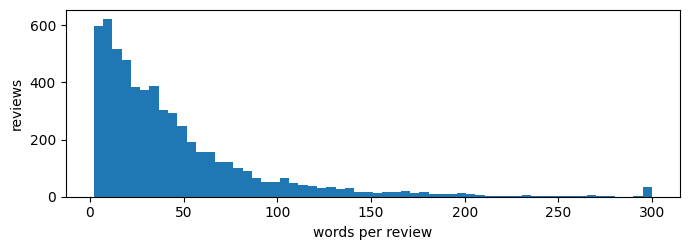

In [5]:
# 2. length
chars = rev.text.str.len()
words = rev.text.str.split().str.len()
for q in (50, 75, 90, 95, 99):
    print(f"p{q:<3} {chars.quantile(q/100):>6.0f} chars   {words.quantile(q/100):>5.0f} words")
print(f"max  {chars.max():>6,} chars")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.hist(np.clip(words, 0, 300), bins=60)
ax.set_xlabel("words per review"); ax.set_ylabel("reviews")
plt.tight_layout(); plt.show()

In [6]:
# 3. format -- decides what normalize() must preserve
import re
checks = {"uppercase": lambda t: t != t.lower(),
          "punctuation": lambda t: bool(re.search(r"[.,!?;:]", t)),
          "digits": lambda t: bool(re.search(r"\d", t)),
          "emoji": lambda t: bool(re.search(r"[\U0001F300-\U0001FAFF]", t)),
          "ALL-CAPS word": lambda t: bool(re.search(r"\b[A-Z]{3,}\b", t))}
for n, fn in checks.items():
    print(f"{n:<16} {rev.text.map(fn).mean():>7.1%}")

uppercase          95.3%
punctuation        77.2%
digits             18.1%
emoji               0.0%
ALL-CAPS word       5.9%


In [7]:
# 4. balance by hotel / source -- is one property dominating?
print(rev.groupby("source").label.value_counts(normalize=True).unstack().round(3))
print()
print("reviews per hotel:")
print(rev.hotel.value_counts().to_string())

label            negative  neutral  positive
source                                      
booking.com         0.329    0.239     0.432
expedia.com         0.222    0.195     0.583
tripadvisor.com     0.207    0.214     0.579

reviews per hotel:
hotel
Ibis Marrakech Centre Gare     906
Ibis Casablanca City Center    838
Ibis Casa Voyageurs            626
Ibis Tanger City Center        612
Ibis Fès                       479
Ibis Ouarzazate Centre         409
Ibis Rabat Agdal               297
Ibis Casablanca Nearshore      269
Ibis El Jadida                 263
Ibis Marrakech Palmeraie       251
Ibis Casa Sidi Maarouf         249
Ibis Abdelmoumen Casa          241
Ibis Mohammedia                183
Ibis Meknès                    129
Ibis Oujda                     120


In [8]:
# 5. how good is the shipped auto-sentiment? -- the baseline to beat.
# Already carried into rev.auto as a per-review majority vote of its sentences.
AUTO_BASELINE = float((rev.auto == rev.label).mean())
print(f"shipped auto-sentiment vs star label: {AUTO_BASELINE:.1%} agreement")
print(pd.crosstab(rev.label, rev.auto))
print()
print("It is biased toward positive: that is why it cannot be training signal.")

shipped auto-sentiment vs star label: 62.5% agreement
auto      negative  neutral  positive
label                                
negative       779      480       272
neutral        279      386       631
positive       102      437      2506

It is biased toward positive: that is why it cannot be training signal.


## Splits

60 / 20 / 20, stratified on the label. Validation is halved again into a
calibration set and a holdout, for the same reason as the French track: fitting
thresholds and measuring the confusion matrix on the same rows makes the
bootstrap interval too narrow.

In [9]:
from sklearn.model_selection import train_test_split
tr, tmp_ = train_test_split(rev, test_size=0.4, stratify=rev.label, random_state=42)
va, te = train_test_split(tmp_, test_size=0.5, stratify=tmp_.label, random_state=42)
calib, hold = train_test_split(va, test_size=0.5, stratify=va.label, random_state=42)

for name, d in [("train", tr), ("val", va), ("  calib", calib), ("  hold", hold), ("test", te)]:
    c = d.label.value_counts()
    print(f"{name:<8} {len(d):>5,}   " +
          "  ".join(f"{k}:{c.get(k,0):>4}" for k in LABELS))

for name, d in [("train", tr), ("calib", calib), ("hold", hold), ("test", te)]:
    d.to_parquet(OUT / f"{name}.parquet") if False else d.to_csv(OUT / f"{name}.csv", index=False)
rev.to_csv(OUT / "reviews_all.csv", index=False)
print(f"\nwrote 5 files to {OUT.name}/")

train    3,523   negative: 918  neutral: 778  positive:1827
val      1,174   negative: 306  neutral: 259  positive: 609
  calib    587   negative: 153  neutral: 129  positive: 305
  hold     587   negative: 153  neutral: 130  positive: 304
test     1,175   negative: 307  neutral: 259  positive: 609



wrote 5 files to data_en/


In [10]:
summary = {"source_file": SRC.name, "language": "English",
           "sentences_en": int(len(en)), "reviews": int(len(rev)),
           "label_counts": {k: int(v) for k, v in rev.label.value_counts().items()},
           "splits": {"train": len(tr), "calib": len(calib), "hold": len(hold), "test": len(te)},
           "words_p50": float(words.quantile(.5)), "words_p90": float(words.quantile(.9)),
           "auto_sentiment_agreement": round(AUTO_BASELINE, 4),
           "normalize_version": NORMALIZE_VERSION}
(OUT / "audit_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "source_file": "df_final_absa_v4.csv",
  "language": "English",
  "sentences_en": 32625,
  "reviews": 5872,
  "label_counts": {
    "positive": 3045,
    "negative": 1531,
    "neutral": 1296
  },
  "splits": {
    "train": 3523,
    "calib": 587,
    "hold": 587,
    "test": 1175
  },
  "words_p50": 31.0,
  "words_p90": 100.0,
  "auto_sentiment_agreement": 0.6252,
  "normalize_version": "v1"
}
